# Exploratory Data Analysis
## Enterprise Supply Chain Operational Risk & Vendor Performance Diagnostics

This notebook walks through the raw data, validates it, and builds the
business case for why a risk scoring system is needed — before we build
the scoring model itself in `src/rule_based_score.py` and `src/train_model.py`.

**Data:** Synthetic but realistically-generated vendor/PO/quality/disruption
data for a global electronics/hardware manufacturer, 2022–2026.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
DATA_DIR = '../data'

vendors = pd.read_csv(f'{DATA_DIR}/vendors.csv')
po = pd.read_csv(f'{DATA_DIR}/purchase_orders.csv', parse_dates=['order_date','promised_delivery_date','actual_delivery_date'])
qi = pd.read_csv(f'{DATA_DIR}/quality_inspections.csv', parse_dates=['inspection_date'])
events = pd.read_csv(f'{DATA_DIR}/disruption_events.csv', parse_dates=['event_date'])
fin = pd.read_csv(f'{DATA_DIR}/vendor_financial_signals.csv')

print(vendors.shape, po.shape, qi.shape, events.shape, fin.shape)
vendors.head()

(70, 10) (5768, 15) (3749, 8) (42, 7) (1260, 5)


,vendor_id,vendor_name,category,country,region,tier,onboarding_date,annual_spend_usd,certifications,single_source_flag
0,V0001,PCB-SOU-1,PCB / PCBA,South Korea,APAC,Tier 3,2021-08-28,247500.0,ISO9001,False
1,V0002,DISP-MEX-2,Displays,Mexico,AMER,Tier 3,2021-07-16,27800.0,"IATF16949, ISO14001, ISO9001, REACH",False
2,V0003,PCB-CHI-3,PCB / PCBA,China,APAC,Tier 2,2019-07-10,1239600.0,"REACH, RoHS",False
3,V0004,SEMI-TAI-4,Semiconductors,Taiwan,APAC,Tier 2,2019-10-31,1129700.0,"ISO9001, REACH, RoHS",True
4,V0005,CONN-JAP-5,Connectors,Japan,APAC,Tier 1,2021-01-13,4216800.0,NaN,False


## 1. Vendor Base Overview

How many vendors, how are they distributed across category/region/tier,
and what does spend concentration look like?

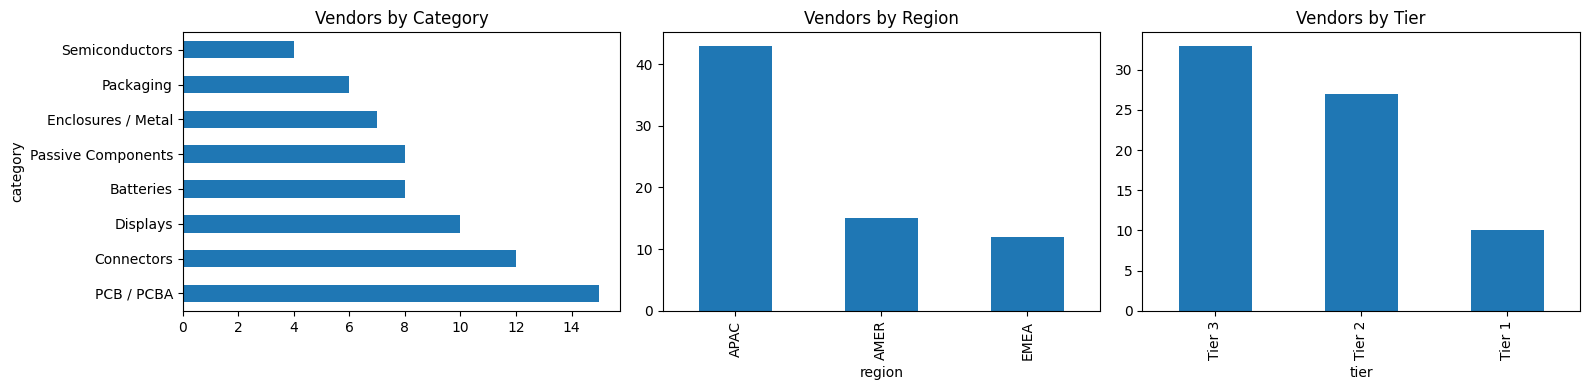

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
vendors['category'].value_counts().plot(kind='barh', ax=axes[0], title='Vendors by Category')
vendors['region'].value_counts().plot(kind='bar', ax=axes[1], title='Vendors by Region')
vendors['tier'].value_counts().plot(kind='bar', ax=axes[2], title='Vendors by Tier')
plt.tight_layout()
plt.show()

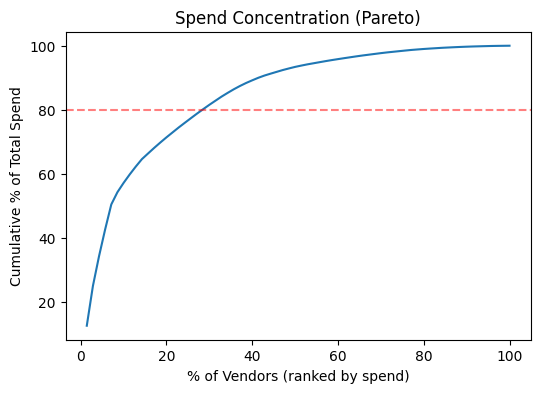

Top 20% of vendors by spend account for 72.9% of total spend


In [3]:
# Spend concentration -- classic 80/20 check
spend_sorted = vendors.sort_values('annual_spend_usd', ascending=False).reset_index(drop=True)
spend_sorted['cum_spend_pct'] = spend_sorted['annual_spend_usd'].cumsum() / spend_sorted['annual_spend_usd'].sum() * 100
spend_sorted['vendor_rank_pct'] = (spend_sorted.index + 1) / len(spend_sorted) * 100

plt.figure(figsize=(6,4))
plt.plot(spend_sorted['vendor_rank_pct'], spend_sorted['cum_spend_pct'])
plt.axhline(80, color='red', linestyle='--', alpha=0.5)
plt.xlabel('% of Vendors (ranked by spend)')
plt.ylabel('Cumulative % of Total Spend')
plt.title('Spend Concentration (Pareto)')
plt.show()

top20pct_cutoff = int(len(spend_sorted) * 0.2)
pct_spend_top20 = spend_sorted.loc[:top20pct_cutoff, 'annual_spend_usd'].sum() / spend_sorted['annual_spend_usd'].sum()
print(f"Top 20% of vendors by spend account for {pct_spend_top20:.1%} of total spend")

**Interview talking point:** this is the classic supply-chain 80/20 rule —
a small number of strategic (Tier 1) vendors carry most of the spend, which
is exactly why they deserve the most rigorous risk monitoring, and why
"concentration risk" (single-source + high-spend) is treated specially in
the scoring methodology rather than being just another averaged metric.

## 2. Delivery Performance

What does on-time delivery look like across the portfolio, and how does it
move over time (do we see the macro disruption windows we built into the
simulation)?

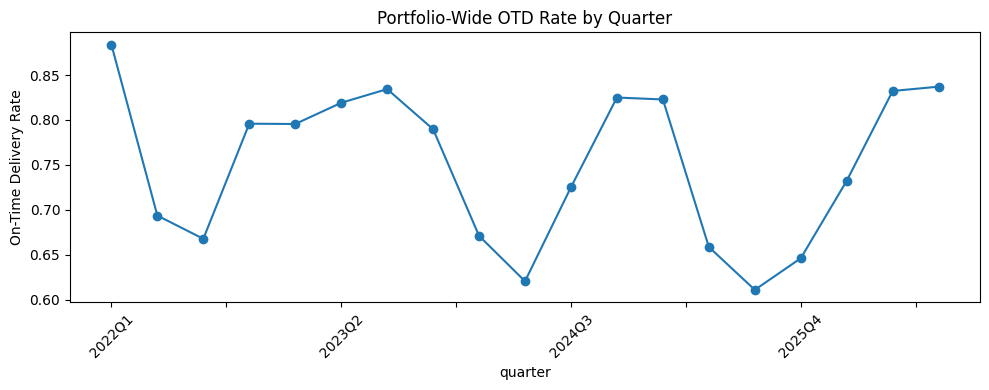

In [4]:
po['on_time'] = po['delay_days'] <= 2
po['quarter'] = po['actual_delivery_date'].dt.to_period('Q').astype(str)

otd_trend = po.groupby('quarter')['on_time'].mean()
plt.figure(figsize=(10,4))
otd_trend.plot(marker='o')
plt.ylabel('On-Time Delivery Rate')
plt.title('Portfolio-Wide OTD Rate by Quarter')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Notice the dips — these align with the macro disruption windows encoded
in `generate_data.py` (2022 chip shortage tail / regional lockdowns, late
2023 Red Sea shipping disruption, 2025 tariff escalation). In a real
company, an analyst would cross-reference dips like these against known
market events to distinguish "our vendor got worse" from "the whole market
got worse" — a distinction that matters a lot for vendor scorecarding
fairness.

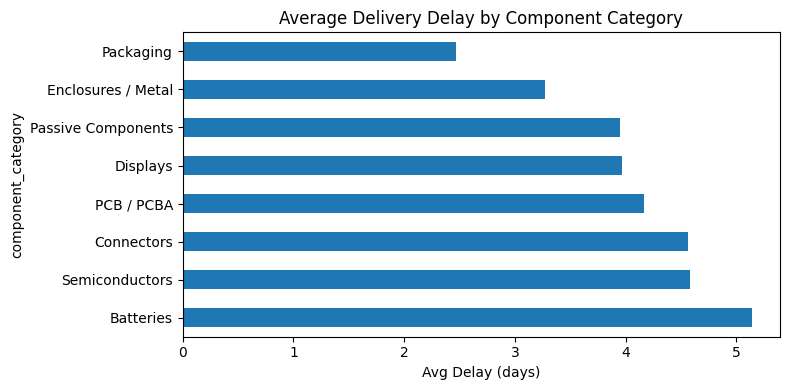

In [5]:
delay_by_category = po.groupby('component_category')['delay_days'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
delay_by_category.plot(kind='barh')
plt.xlabel('Avg Delay (days)')
plt.title('Average Delivery Delay by Component Category')
plt.tight_layout()
plt.show()

## 3. Quality Signals

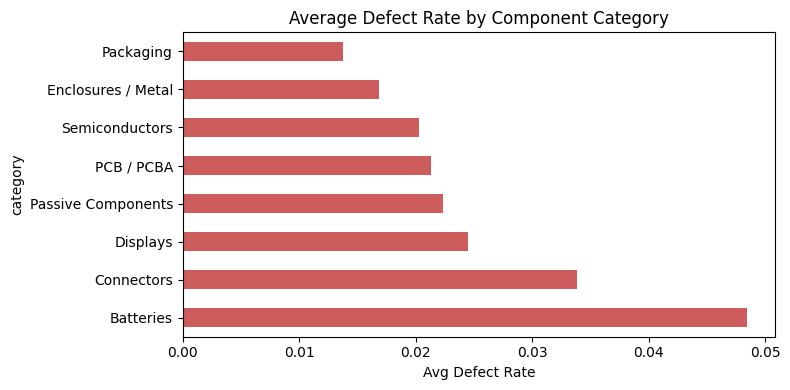

In [6]:
defect_by_category = qi.merge(vendors[['vendor_id','category']], on='vendor_id').groupby('category')['defect_rate'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,4))
defect_by_category.plot(kind='barh', color='indianred')
plt.xlabel('Avg Defect Rate')
plt.title('Average Defect Rate by Component Category')
plt.tight_layout()
plt.show()

## 4. Disruption Events

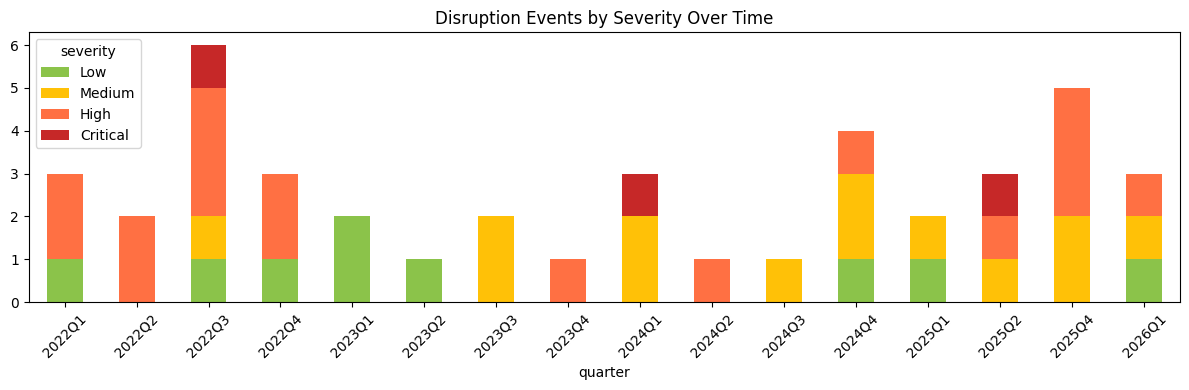

In [7]:
events['quarter'] = events['event_date'].dt.to_period('Q').astype(str)
severity_counts = events.groupby(['quarter','severity']).size().unstack(fill_value=0)
severity_counts = severity_counts.reindex(columns=['Low','Medium','High','Critical'], fill_value=0)

severity_counts.plot(kind='bar', stacked=True, figsize=(12,4),
                      color=['#8bc34a','#ffc107','#ff7043','#c62828'])
plt.title('Disruption Events by Severity Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Key Takeaways (feed into scoring methodology)

1. Delivery reliability and quality vary meaningfully by component category
   — semiconductors and displays carry structurally higher lead-time risk,
   which is realistic (long fabrication cycles, few global suppliers).
2. Portfolio-wide OTD dips coincide with simulated macro disruption windows,
   confirming vendor performance isn't purely idiosyncratic — market shocks
   propagate through the whole portfolio, which argues for a scoring model
   that can separate "vendor-specific" risk from "market-wide" risk.
3. Spend is concentrated in a minority of vendors (Pareto pattern), which is
   why concentration/single-source risk needs its own treatment in the
   scoring methodology rather than being diluted into an averaged score.

These findings directly motivate the design choices in
`src/rule_based_score.py` (weighted, category-aware scoring with a
concentration-risk multiplier) and `src/train_model.py` (a model that
learns from trailing signals to anticipate next-quarter risk rather than
just describing the past).
